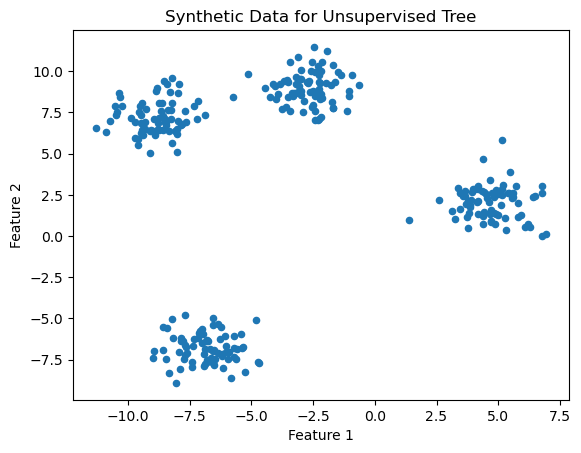

In [1]:
from sklearn.datasets import make_blobs 
import matplotlib.pyplot as plt 
# Generate synthetic data with clear clusters 
X, _ = make_blobs(n_samples=300, centers=4, n_features=2, random_state=42) 
plt.scatter(X[:, 0], X[:, 1], s=20) 
plt.title("Synthetic Data for Unsupervised Tree") 
plt.xlabel("Feature 1") 
plt.ylabel("Feature 2") 
plt.show() 

In [2]:
import numpy as np 
from sklearn.metrics import silhouette_score 
 
def best_split(X, min_leaf_size=5): 
    best_score = -1 
    best_feature, best_threshold = None, None 
    n_samples, n_features = X.shape 
     
    for f in range(n_features): 
        thresholds = np.unique(X[:, f]) 
        for t in thresholds: 
            left_mask = X[:, f] <= t 
            right_mask = ~left_mask 
            if left_mask.sum() < min_leaf_size or right_mask.sum() < min_leaf_size: 
                continue 
             
            labels = np.zeros(n_samples) 
            labels[right_mask] = 1 
            score = silhouette_score(X, labels) 
             
            if score > best_score: 
                best_score = score 
                best_feature, best_threshold = f, t 
     
    return best_feature, best_threshold, best_score 

Best split on feature 1, threshold -4.788, silhouette score = 0.590


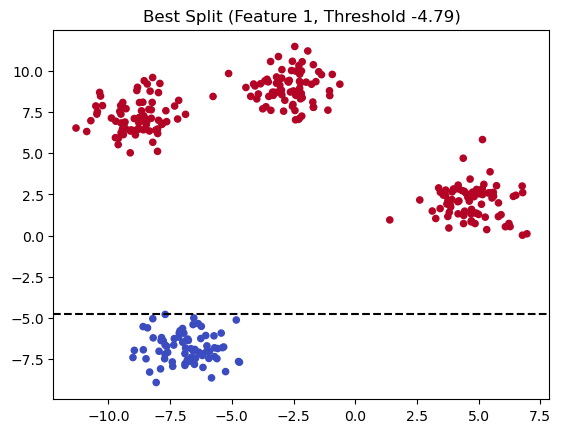

In [3]:
feature, threshold, score = best_split(X) 
print(f"Best split on feature {feature}, threshold {threshold:.3f}, silhouette score = {score:.3f}") 
 
plt.scatter(X[:, 0], X[:, 1], c=(X[:, feature] > threshold), cmap='coolwarm', s=20) 
if feature == 0: 
    plt.axvline(threshold, color='k', linestyle='--') 
else: 
    plt.axhline(threshold, color='k', linestyle='--') 
plt.title(f"Best Split (Feature {feature}, Threshold {threshold:.2f})") 
plt.show() 

In [6]:
class UnsupervisedTree: 
    def __init__(self, min_leaf_size=10, min_gain=0.01, depth=0, max_depth=3): 
        self.min_leaf_size = min_leaf_size 
        self.min_gain = min_gain 
        self.depth = depth 
        self.max_depth = max_depth 
        self.is_leaf = False 
 
    def fit(self, X): 
        if self.depth >= self.max_depth: 
            self.is_leaf = True 
            return 
         
        feature, threshold, score = best_split(X, self.min_leaf_size) 
        if feature is None or score < self.min_gain: 
            self.is_leaf = True 
            return 
         
        self.feature, self.threshold, self.score = feature, threshold, score 
        left_mask = X[:, feature] <= threshold 
        right_mask = ~left_mask 
 
        self.left = UnsupervisedTree(self.min_leaf_size, self.min_gain, self.depth+1,self.max_depth) 
        self.right = UnsupervisedTree(self.min_leaf_size, self.min_gain, self.depth+1, self.max_depth) 
        self.left.fit(X[left_mask]) 
        self.right.fit(X[right_mask]) 
         
    def predict(self, X): 
        if self.is_leaf: 
            return np.zeros(X.shape[0]) + self.depth 
        mask = X[:, self.feature] > self.threshold 
        left_labels = self.left.predict(X[~mask]) 
        right_labels = self.right.predict(X[mask]) + 1 
        labels = np.zeros(X.shape[0]) 
        labels[~mask] = left_labels 
        labels[mask] = right_labels 
        return labels

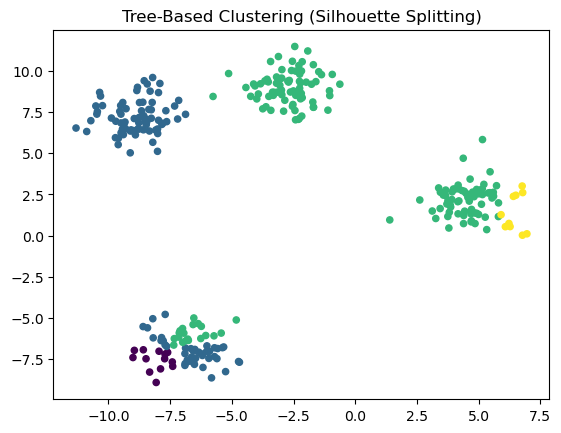

In [7]:
tree = UnsupervisedTree(max_depth=3, min_leaf_size=10) 
tree.fit(X) 
labels = tree.predict(X) 
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=20) 
plt.title("Tree-Based Clustering (Silhouette Splitting)") 
plt.show()

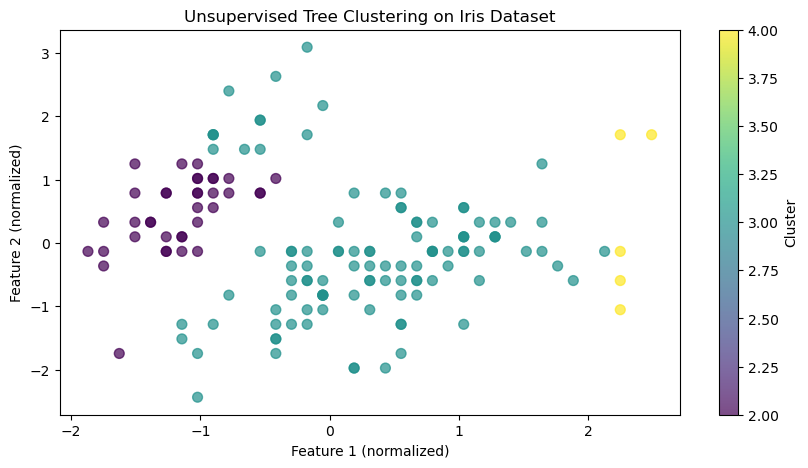

Found 5 clusters
Silhouette Score: 0.290


In [8]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load and preprocess Iris dataset
iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)

# Apply unsupervised tree
tree_iris = UnsupervisedTree(max_depth=2, min_leaf_size=5)
tree_iris.fit(X_iris)
labels_iris = tree_iris.predict(X_iris)

# Visualize (using first 2 features)
plt.figure(figsize=(10, 5))
plt.scatter(X_iris[:, 0], X_iris[:, 1], c=labels_iris, cmap='viridis', s=50, alpha=0.7)
plt.xlabel('Feature 1 (normalized)')
plt.ylabel('Feature 2 (normalized)')
plt.title('Unsupervised Tree Clustering on Iris Dataset')
plt.colorbar(label='Cluster')
plt.show()

print(f"Found {int(labels_iris.max()) + 1} clusters")
print(f"Silhouette Score: {silhouette_score(X_iris, labels_iris):.3f}")

### 8.3: Apply to Real Dataset (Iris)

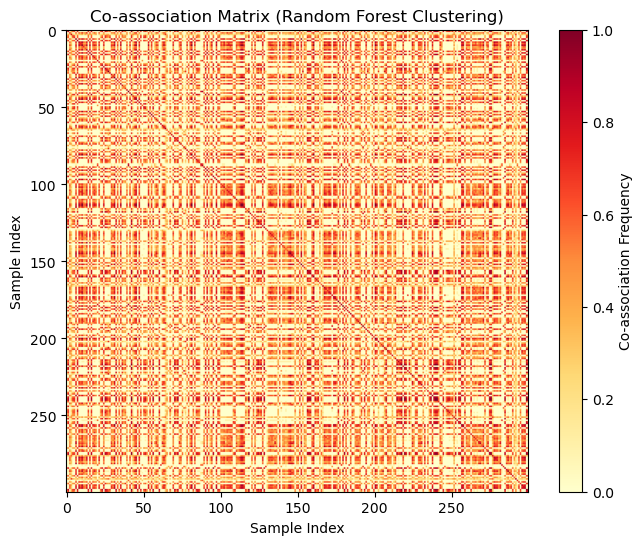

In [9]:
class RandomForestClustering:
    """Ensemble of unsupervised trees with co-association matrix."""
    
    def __init__(self, n_trees=5, max_depth=3, subsample_ratio=0.8):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.subsample_ratio = subsample_ratio
        self.trees = []
    
    def fit(self, X):
        n_samples = X.shape[0]
        subsample_size = int(n_samples * self.subsample_ratio)
        
        for _ in range(self.n_trees):
            idx = np.random.choice(n_samples, subsample_size, replace=False)
            X_subset = X[idx]
            tree = UnsupervisedTree(max_depth=self.max_depth)
            tree.fit(X_subset)
            self.trees.append((tree, idx))
    
    def get_coassociation_matrix(self, X):
        """Build co-association matrix: how often samples are in same cluster."""
        n_samples = X.shape[0]
        coassoc = np.zeros((n_samples, n_samples))
        
        for tree, idx in self.trees:
            labels = tree.predict(X[idx])
            for i, si in enumerate(idx):
                for j, sj in enumerate(idx):
                    if labels[i] == labels[j]:
                        coassoc[si, sj] += 1
        
        return coassoc / self.n_trees

# Example: Random Forest Clustering
rfc = RandomForestClustering(n_trees=10, max_depth=3)
rfc.fit(X)
coassoc_matrix = rfc.get_coassociation_matrix(X)

# Visualize co-association
plt.figure(figsize=(8, 6))
plt.imshow(coassoc_matrix, cmap='YlOrRd')
plt.colorbar(label='Co-association Frequency')
plt.title('Co-association Matrix (Random Forest Clustering)')
plt.xlabel('Sample Index')
plt.ylabel('Sample Index')
plt.show()

### 8.2: Random Forest Clustering with Co-association Matrix

In [10]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

def best_split_with_indices(X, min_leaf_size=5):
    """Evaluate splits using multiple quality indices."""
    best_score = -1
    best_feature, best_threshold = None, None
    best_scores = {}
    n_samples, n_features = X.shape
    
    for f in range(n_features):
        thresholds = np.unique(X[:, f])
        for t in thresholds:
            left_mask = X[:, f] <= t
            right_mask = ~left_mask
            if left_mask.sum() < min_leaf_size or right_mask.sum() < min_leaf_size:
                continue
            
            labels = np.zeros(n_samples)
            labels[right_mask] = 1
            
            silhouette = silhouette_score(X, labels)
            db = davies_bouldin_score(X, labels)
            ch = calinski_harabasz_score(X, labels)
            
            if silhouette > best_score:
                best_score = silhouette
                best_feature, best_threshold = f, t
                best_scores = {'silhouette': silhouette, 'davies_bouldin': db, 'calinski_harabasz': ch}
    
    return best_feature, best_threshold, best_scores

# Example
feature, threshold, scores = best_split_with_indices(X)
print(f"Best split - Feature {feature}, Threshold {threshold:.3f}")
for metric, value in scores.items():
    print(f"  {metric}: {value:.3f}")

Best split - Feature 1, Threshold -4.788
  silhouette: 0.590
  davies_bouldin: 0.525
  calinski_harabasz: 333.488


## 8. Optional Extensions

### 8.1: Alternative Cluster Quality Indices

Implement Davies-Bouldin and Calinski-Harabasz indices:

## 7. Discussion Questions

1. **How does this method differ from k-means or hierarchical clustering?**
   - This unsupervised tree doesn't require specifying k in advance; it builds a hierarchical structure recursively. Unlike k-means (flat clustering), it captures multi-level clustering patterns. Unlike hierarchical clustering, it uses Silhouette score as the splitting criterion, optimizing for cluster cohesion at each step.

2. **What role does the Silhouette score play here compared to Gini impurity?**
   - Silhouette score measures cluster quality (how well-separated clusters are), while Gini impurity measures class purity. Here, Silhouette directly optimizes for interpretable, well-separated clusters rather than minimizing within-class variance.

3. **How do parameters like min_leaf_size and max_depth influence the result?**
   - `max_depth` limits tree depth, controlling the number of clusters (more depth = more clusters). `min_leaf_size` prevents creating overly small clusters, reducing noise and over-segmentation.

4. **Could you ensemble several such trees (with random subsets of features/data) to create a 'Random Forest Clustering'?**
   - Yes! Multiple trees trained on random subsets create diverse partitions. A co-association matrix aggregates their cluster assignments to find stable, robust clusters.